In [1]:
!pip install pandas numpy matplotlib seaborn
!pip install mne scipy jupyter
!pip install PyQt6

In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.datasets import eegbci

mne.viz.set_browser_backend("qt")

Using qt as 2D backend.


## Load data

In [3]:
# Code partially obtained from dataset documentation: https://data-brain-mind.github.io/tutorials/reading-observed-at-mindless-moments-roamm-a-simultaneous-eeg-and-eye-tracking-dataset-of-natural-reading-with-attention-annotations/
# define data root
# this is the path to the ROAMM folder on local machine
roamm_root = r"./data"
ml_data_root = os.path.join(roamm_root, 'subject_ml_data')

In [4]:
# Select one subject and run number to test with
subject_id = 's10014'
subject_dir = os.path.join(ml_data_root, subject_id)
run_number = 1
df_run = pd.read_pickle(os.path.join(subject_dir, f'{subject_id}_run{run_number}_ml_data.pkl')) # Load that file
df_run_filtered = df_run[df_run.first_pass_reading==True] # Filter for only data points where the participant is actually reading the text (not reading instructions or performing a MW check)

# Channels to filter for later
EEG_cols = ['Fp1',  'AF7',  'AF3',  'F1',  'F3',  'F5',  'F7',  'FT7',  'FC5',  'FC3',  'FC1',  'C1',  'C3',  'C5',  'T7',  'TP7',  'CP5',  'CP3',  'CP1',  'P1',  'P3',  'P5',  'P7',  'P9',  'PO7',  'PO3',  'O1',  'Iz',  'Oz',  'POz',  'Pz',  'CPz',  'Fpz',  'Fp2',  'AF8',  'AF4',  'Afz',  'Fz',  'F2',  'F4',  'F6',  'F8',  'FT8',  'FC6',  'FC4',  'FC2',  'FCz',  'Cz',  'C2',  'C4',  'C6',  'T8',  'TP8',  'CP6',  'CP4',  'CP2',  'P2',  'P4',  'P6',  'P8',  'P10',  'PO8',  'PO4',  'O2']

# Relevant description columns
exp_cols = ['time','is_mw', 'mw_onset', 'mw_offset', 'mw_dur']

In [5]:
display(df_run_filtered[EEG_cols+exp_cols].head())
display([*df_run_filtered.columns])

,Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,...,P8,P10,PO8,PO4,O2,time,is_mw,mw_onset,mw_offset,mw_dur
3215,-0.000001,0.000001,-3.233485e-06,-0.000002,-3.570374e-06,-3.794776e-06,9.564145e-07,-0.000006,-6.211175e-07,4.306251e-07,...,6.385265e-06,-9.651197e-08,3.590585e-06,-0.000002,0.000002,12.558594,NaN,NaN,NaN,NaN
3216,0.000005,0.000001,9.098603e-08,0.000001,-7.429804e-07,-2.627195e-06,-2.663648e-06,-0.000008,-1.114337e-06,2.025536e-06,...,3.646609e-06,-2.481566e-06,-2.408371e-07,-0.000006,-0.000002,12.562500,NaN,NaN,NaN,NaN
3217,0.000010,0.000003,3.404914e-06,0.000002,2.027947e-06,-4.891517e-08,-2.246929e-06,-0.000006,-2.427471e-07,3.729228e-06,...,6.790179e-07,-1.695545e-06,-1.588166e-06,-0.000009,-0.000004,12.566406,NaN,NaN,NaN,NaN
3218,0.000010,0.000006,4.720883e-06,0.000002,3.039013e-06,2.077813e-06,2.598019e-06,-0.000002,2.181295e-06,4.819751e-06,...,-7.030773e-07,1.243187e-06,-4.147942e-08,-0.000009,-0.000004,12.570312,NaN,NaN,NaN,NaN
3219,0.000004,0.000008,3.584969e-06,0.000001,1.631473e-06,2.969682e-06,9.137543e-06,0.000003,5.203575e-06,4.801439e-06,...,-1.401352e-06,2.544503e-06,1.898883e-06,-0.000007,-0.000002,12.574219,NaN,NaN,NaN,NaN


['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'Afz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2',
 'time',
 'sfreq',
 'first_pass_reading',
 'page_num',
 'page_start',
 'page_end',
 'page_dur',
 'is_mw',
 'mw_onset',
 'mw_offset',
 'mw_dur',
 'run_num',
 'story_name',
 'is_fix',
 'fix_L_eye',
 'fix_L_tStart',
 'fix_L_tEnd',
 'fix_L_duration',
 'fix_L_xAvg',
 'fix_L_yAvg',
 'fix_L_pupilAvg',
 'fix_L_fixed_word',
 'fix_L_fixed_word_key',
 'fix_R_eye',
 'fix_R_tStart',
 'fix_R_tEnd',
 'fix_R_duration',
 'fix_R_xAvg',
 'fix_R_yAvg',
 'fix_R_pupilAvg',
 'fix_R_fixed_word',
 'fix_R_fixed_word_key',
 'is_blink',
 'bli

### Create MNE Array object

In [6]:

eeg_data = df_run_filtered[EEG_cols+exp_cols]
eeg_data["is_mw"] = eeg_data["is_mw"].replace(np.nan, False) # Replace NaN with False in the MW column

eeg_dataT = eeg_data.values.T  # Transpose to (n_channels, n_samples)

# Create channel information
n_channels = eeg_dataT.shape[0]
ch_names = eeg_data.columns.tolist()  # Or specify your channel names
ch_types = ['eeg'] * n_channels  # All channels are EEG

# Create info object
info = mne.create_info(ch_names=ch_names, 
                       sfreq=256,  # Replace with your sampling frequency in Hz
                       ch_types=ch_types)

# Create Raw object
raw = mne.io.RawArray(eeg_dataT, info)

# Set channel types for experiment details
raw.set_channel_types({
    'time': 'syst',
    'is_mw': 'stim',
    'mw_onset': 'stim',
    'mw_offset': 'stim',
    'mw_dur': 'stim'
})

# Detect events and convert to annotations
events = mne.find_events(raw, stim_channel="is_mw")
print(events)

annot_from_events = mne.annotations_from_events(
    events=events,
    event_desc={0: "noMW", 1:"MW"},
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)

# Add annotations
raw.set_annotations(annot_from_events)

Creating RawArray with float64 data, n_channels=69, n_times=54052
    Range : 0 ... 54051 =      0.000 ...   211.137 secs
Ready.
Finding events on: is_mw
10 events found on stim channel is_mw
Event IDs: [1]
[[ 1579     0     1]
 [13411     0     1]
 [16198     0     1]
 [25146     0     1]
 [30758     0     1]
 [32620     0     1]
 [35858     0     1]
 [39343     0     1]
 [44624     0     1]
 [50447     0     1]]


/tmp/ipykernel_53537/724557917.py:20: RuntimeWarning: The unit for channel(s) time has changed from V to NA.
  raw.set_channel_types({


<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

In [7]:
raw.annotations

<Annotations | 10 segments: MW (10)>

In [ ]:
raw.plot()
plt.show()

Channels marked as bad:
none


In [9]:
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("biosemi64")
raw.set_montage(montage)

<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

### Make visualizations

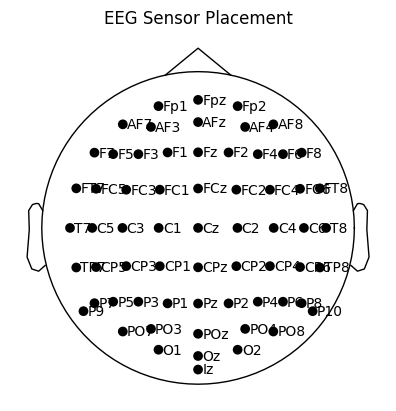

In [10]:
# EEG sensor placements
fig,ax = plt.subplots()
ax.set_title("EEG Sensor Placement")
raw.plot_sensors(show_names=True, axes=ax, kind='topomap', ch_type='eeg')
plt.show()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


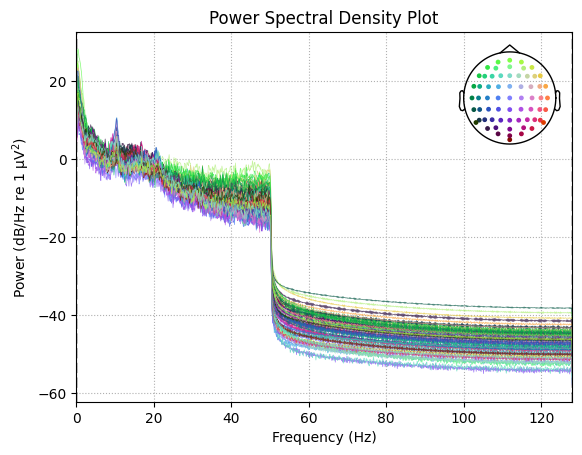

In [11]:
fig,ax = plt.subplots()
raw.compute_psd().plot(axes=ax)
ax.set_title("Power Spectral Density Plot")
plt.show()

Effective window size : 8.000 (s)


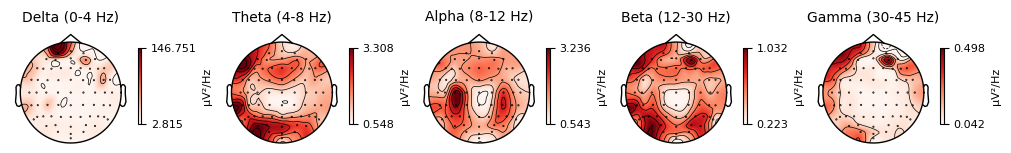

In [12]:
raw.compute_psd().plot_topomap()
plt.show()

In [13]:
raw

<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

## Full data pre-processing pipeline

In [2]:
def load_data(path):
    # Get subject ID
    subject_id = path.split("/")[3]

    # Load file at path
    df_run = pd.read_pickle(path) # Load that file
    df_run_filtered = df_run[df_run.first_pass_reading==True] # Filter for only data points where the participant is actually reading the text (not reading instructions or performing a MW check)

    eeg_data = df_run_filtered[EEG_cols]
    labels = df_run_filtered["is_mw"].replace(np.nan, False) # Replace NaN with False in the MW column

    eeg_dataT = eeg_data.values.T  # Transpose to (n_channels, n_samples)

    # Create channel information
    n_channels = eeg_dataT.shape[0]
    ch_names = eeg_data.columns.tolist()  # Or specify your channel names
    ch_types = ['eeg'] * n_channels  # All channels are EEG

    # Create info object
    info = mne.create_info(ch_names=ch_names, 
                        sfreq=256,
                        ch_types=ch_types)

    # Create Raw object
    eeg = mne.io.RawArray(eeg_dataT, info, verbose="WARNING")

    return subject_id, eeg, labels

In [3]:
def preprocess_data(X_data, y, subject_id, window_size):
    """
    X_data: MNE object with EEG data as features
    y: binary mind wandering label
    subject_id: identifier for subject
    window_size: window size in ms
    """
    # New dataframe for labels and predictors
    df_out = pd.DataFrame(columns=["subject", "delta","theta","alpha", "beta", "gamma", "is_mw"])

    for i in range(0, len(X_data), int(window_size/2)): # This adds a 50% overlap between neighboring windows to prevent short mind wandering periods from being missed through majority voting
        psd = X_data.compute_psd(method="welch", verbose="WARNING", fmin=1.0, fmax=80.0, tmin=i/1000, tmax=(i+window_size)/1000)

        psds, freqs = psd.get_data(return_freqs=True)

        #This creates masks for certain frequency ranges
        delta_mask = (freqs >= 1.0) & (freqs < 4.0)
        theta_mask = (freqs >= 4.0) & (freqs < 8.0)
        alpha_mask = (freqs >= 8.0) & (freqs < 12.0)
        beta_mask  = (freqs >= 12.0) & (freqs < 30.0)
        gamma_mask = (freqs >= 30.0) & (freqs < 45.0)

        delta_power_per_channel = psds[:, delta_mask].mean(axis=1)
        theta_power_per_channel = psds[:, theta_mask].mean(axis=1)
        alpha_power_per_channel = psds[:, alpha_mask].mean(axis=1)
        beta_power_per_channel  = psds[:, beta_mask].mean(axis=1)
        gamma_power_per_channel  = psds[:, gamma_mask].mean(axis=1)

        # Calculate features (average of amplitude per frequency band)
        delta_avg = delta_power_per_channel.mean()
        theta_avg = theta_power_per_channel.mean()
        alpha_avg = alpha_power_per_channel.mean()
        beta_avg = beta_power_per_channel.mean()
        gamma_avg = gamma_power_per_channel.mean()

        # Set target label (mind wandering)
        label = y.iloc[i:(i+window_size)].median() # Majority vote regarding mind-wandering label
        
        # Save to new row
        df_out.loc[len(df_out)] = [subject_id, delta_avg,theta_avg,alpha_avg,beta_avg,gamma_avg,label]

    return df_out

In [4]:
# Code partially obtained from dataset documentation: https://data-brain-mind.github.io/tutorials/reading-observed-at-mindless-moments-roamm-a-simultaneous-eeg-and-eye-tracking-dataset-of-natural-reading-with-attention-annotations/
# Define data root
roamm_root = r"./data"
ml_data_root = os.path.join(roamm_root, 'subject_ml_data')

# Channels to filter for later
EEG_cols = ['Fp1',  'AF7',  'AF3',  'F1',  'F3',  'F5',  'F7',  'FT7',  'FC5',  'FC3',  'FC1',  'C1',  'C3',  'C5',  'T7',  'TP7',  'CP5',  'CP3',  'CP1',  'P1',  'P3',  'P5',  'P7',  'P9',  'PO7',  'PO3',  'O1',  'Iz',  'Oz',  'POz',  'Pz',  'CPz',  'Fpz',  'Fp2',  'AF8',  'AF4',  'Afz',  'Fz',  'F2',  'F4',  'F6',  'F8',  'FT8',  'FC6',  'FC4',  'FC2',  'FCz',  'Cz',  'C2',  'C4',  'C6',  'T8',  'TP8',  'CP6',  'CP4',  'CP2',  'P2',  'P4',  'P6',  'P8',  'P10',  'PO8',  'PO4',  'O2']

# Parameters
window_size = 250

In [5]:

for window_size in [5000, 3000, 2000, 1000, 500, 250]:
    df_processed = pd.DataFrame(columns=["subject","delta","theta","alpha", "beta", "gamma", "is_mw"])

    # For debugging purposes
    invalid_files = []

    # File processing
    for path in glob(ml_data_root + "/*/*.pkl"):
        try:
            # Load data
            subject_id, eeg, labels = load_data(path)

            # Compute amplitude averages per frequency band per window
            df_processed_subject = preprocess_data(eeg, labels, subject_id, window_size)
            df_processed = pd.concat([df_processed, df_processed_subject], ignore_index=True)
        except:
            invalid_files.append(path)

    # Filter extreme values
    df_filtered = df_processed.copy()
    for column in ["delta","theta","alpha", "beta", "gamma"]:
        upper = df_processed[column].mean() + 5 * df_processed[column].std()
        outliers = df_filtered[df_filtered[column] > upper]
        if (not outliers.empty):
            print(f"Removed the following {len(outliers)} rows as outliers in the {column} frequency band (> {upper:.3}). {outliers['is_mw'].mean()*100:.3}% MW")
            display(outliers)
        df_filtered = df_filtered[df_filtered[column] <= upper]

    # Normalization separately for each frequency band (as value ranges between these bands vary)
    for freq_band in ["delta", "theta", "alpha", "beta", "gamma"]:
        df_filtered[freq_band] -= df_filtered[freq_band].mean() # Mean centering
        df_filtered[freq_band] /= df_filtered[freq_band].std() # Normalization for each 

    # Saving preprocessed data
    df_filtered.to_pickle(f"data/preprocessed/data_{window_size}ms.pkl")
    df_filtered.to_csv(f"data/preprocessed/data_{window_size}ms.csv")

    # Printing output
    display(df_filtered)
    if len(invalid_files) > 0:
        print("The following files could not be processed:")
        for file in invalid_files:
            print(f"- {file}")

Removed the following 3 rows as outliers in the delta frequency band (> 9.01e-12). 1e+02% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
836,s10052,0.0,0.0,0.0,0.0,0.0,1.0
839,s10052,0.0,0.0,0.0,0.0,0.0,1.0
840,s10052,0.0,0.0,0.0,0.0,0.0,1.0


Removed the following 5 rows as outliers in the theta frequency band (> 6.46e-12). 0.0% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
248,s10081,0.0,0.0,0.0,0.0,0.0,0.0
250,s10081,0.0,0.0,0.0,0.0,0.0,0.0
251,s10081,0.0,0.0,0.0,0.0,0.0,0.0
276,s10081,0.0,0.0,0.0,0.0,0.0,0.0
329,s10081,0.0,0.0,0.0,0.0,0.0,0.0


Removed the following 2 rows as outliers in the alpha frequency band (> 5.69e-12). 50.0% MW


...

Removed the following 56 rows as outliers in the beta frequency band (> 1.73e-12). 23.2% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
49,s10014,0.0,0.0,0.0,0.0,0.0,0.0
153,s10014,0.0,0.0,0.0,0.0,0.0,0.0
161,s10014,0.0,0.0,0.0,0.0,0.0,0.0
228,s10014,0.0,0.0,0.0,0.0,0.0,0.0
259,s10014,0.0,0.0,0.0,0.0,0.0,0.0
401,s10014,0.0,0.0,0.0,0.0,0.0,0.0
547,s10014,0.0,0.0,0.0,0.0,0.0,1.0
880,s10014,0.0,0.0,0.0,0.0,0.0,0.0
1249,s10014,0.0,0.0,0.0,0.0,0.0,0.0
1355,s10014,0.0,0.0,0.0,0.0,0.0,0.0


Removed the following 39 rows as outliers in the gamma frequency band (> 7.95e-13). 12.8% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
23,s10014,0.0,0.0,0.0,0.0,0.0,0.0
32,s10014,0.0,0.0,0.0,0.0,0.0,0.0
2030,s10014,0.0,0.0,0.0,0.0,0.0,0.0
3814,s10081,0.0,0.0,0.0,0.0,0.0,0.0
6980,s10085,0.0,0.0,0.0,0.0,0.0,0.0
7001,s10085,0.0,0.0,0.0,0.0,0.0,0.0
7566,s10085,0.0,0.0,0.0,0.0,0.0,0.0
9996,s10085,0.0,0.0,0.0,0.0,0.0,0.0
14805,s10052,0.0,0.0,0.0,0.0,0.0,0.0
14807,s10052,0.0,0.0,0.0,0.0,0.0,0.0


,subject,delta,theta,alpha,beta,gamma,is_mw
0,s10014,0.890442,-0.263547,-0.644435,0.530538,-0.358633,0.0
1,s10014,-0.880843,-0.313645,0.900725,0.907764,-0.186348,0.0
2,s10014,-0.190379,-0.294007,-0.870132,-0.65287,0.491078,0.0
3,s10014,-0.182124,0.84369,1.428043,0.530563,1.910765,0.0
4,s10014,1.580447,0.705979,-0.516758,0.099607,-0.306508,0.0
...,...,...,...,...,...,...,...
18170,s10052,0.900867,0.183025,-0.40695,-0.730039,0.995043,0.0
18171,s10052,-0.81865,-0.39468,-0.261423,-0.928948,-0.889323,0.0
18172,s10052,-0.8339,-0.733206,-0.508532,-0.456276,-0.789598,0.0
18173,s10052,-0.101217,0.013874,-0.435866,-0.804402,-0.298119,0.0


Text(0, 0.5, 'Percentage of samples')

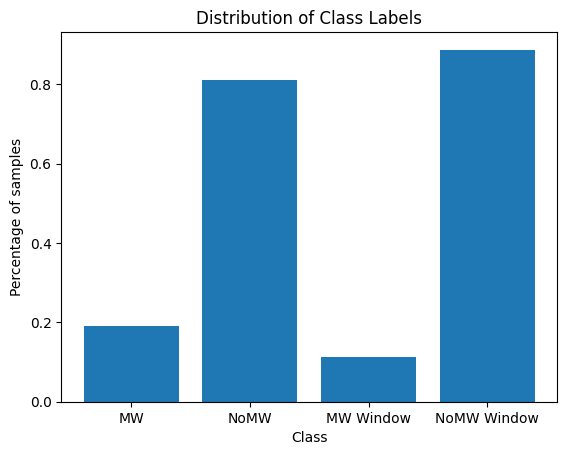

In [6]:
plt.bar(
    ["MW", "NoMW", "MW Window", "NoMW Window"],
    [
        labels.mean(),
        1-labels.mean(),
        df_filtered["is_mw"].mean(),
        1-(df_filtered["is_mw"].mean())
    ]
)

plt.title("Distribution of Class Labels")
plt.xlabel("Class")
plt.ylabel("Percentage of samples")

<Axes: >

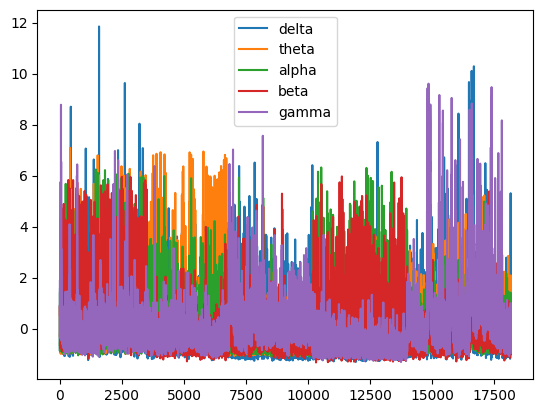

In [7]:
df_filtered[["delta", "theta", "alpha", "beta","gamma"]].plot()

Text(0, 0.5, 'Mean Amplitude')

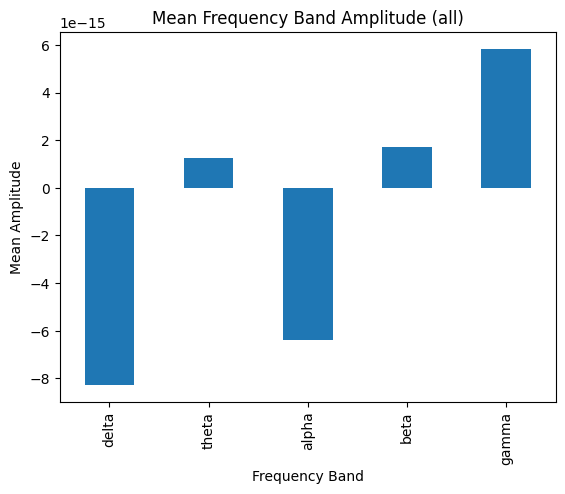

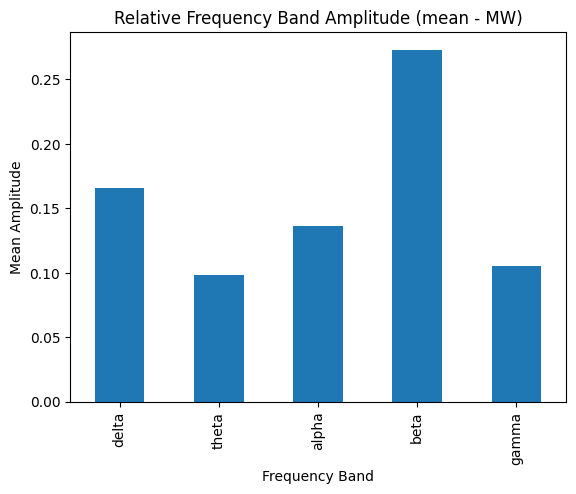

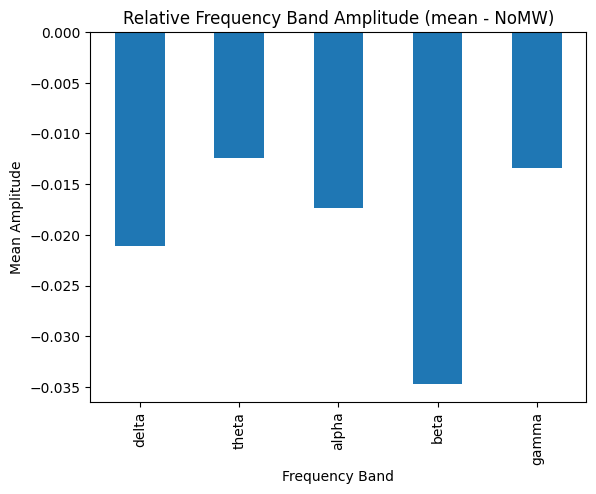

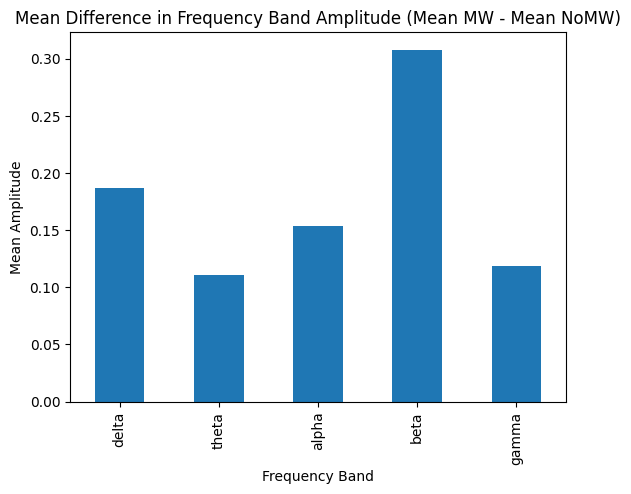

In [8]:
mean_all = df_filtered[["delta", "theta", "alpha", "beta","gamma"]].mean()
mean_mw = df_filtered[df_filtered.is_mw == True][["delta", "theta", "alpha", "beta","gamma"]].mean()
mean_nomw = df_filtered[df_filtered.is_mw == False][["delta", "theta", "alpha", "beta","gamma"]].mean()

fig,ax = plt.subplots()
(mean_all).plot.bar(ax=ax)
ax.set_title("Mean Frequency Band Amplitude (all)")
ax.set_xlabel("Frequency Band")
ax.set_ylabel("Mean Amplitude")

fig,ax = plt.subplots()
(mean_mw - mean_all).plot.bar(ax=ax)
ax.set_title("Relative Frequency Band Amplitude (mean - MW)")
ax.set_xlabel("Frequency Band")
ax.set_ylabel("Mean Amplitude")

fig, ax = plt.subplots()
(mean_nomw - mean_all).plot.bar(ax=ax)
ax.set_title("Relative Frequency Band Amplitude (mean - NoMW)")
ax.set_xlabel("Frequency Band")
ax.set_ylabel("Mean Amplitude")

fig, ax = plt.subplots()
(mean_mw - mean_nomw).plot.bar(ax=ax)
ax.set_title("Mean Difference in Frequency Band Amplitude (Mean MW - Mean NoMW)")
ax.set_xlabel("Frequency Band")
ax.set_ylabel("Mean Amplitude")

# fig, ax = plt.subplots()
# (((mean_mw - mean_nomw)/mean_mw)*100).plot.bar(ax=ax)
# ax.set_title("Percentage Difference in Frequency Band Amplitude")
# ax.set_xlabel("Frequency Band")
# ax.set_ylabel("Percentage Amplitude Difference")


## Insights from data exploration
<b>Class distribution</b><br>
<i>It seems the 'no mind wandering' class is heavily overrepresented in the original dataset. Though this is a realistic distribution of states and not a flaw in measurement, this could still lead to overfitting and poor performance. Due to the imbalanced dataset, we should use evaluation metrics that take this into account.

Additionally, the averaging per window has lead to an increase in this imbalance, which is something to might need to be addressed if performance is poor.</i>

<b>Mean Frequency Band Amplitudes</b><br>
<i>The relative activity in either class is very comparable. However, the amplitude clearly differs between the mind wandering (MW) and no mind wandering (NoMW) states. During mind wandering, activity across all frequency bands increased. Especially the delta band saw a significant increase.</i>
